# CTR AB test analysis

In [ ]:
import numpy as np
import pandas as pd
from scipy.special import expit, logit
import statsmodels.api as sm

np.random.seed(11)

# -------------------------
# 1) Make a toy dataset
# -------------------------
n_merchants = 80
treat = np.random.binomial(1, 0.5, size=n_merchants)          # merchant-randomized
quality = np.random.normal(0, 0.7, size=n_merchants)          # merchant heterogeneity

# Keep denominators modest so we can expand to impression-level later
impr_pre = np.random.lognormal(mean=np.log(250), sigma=0.35, size=n_merchants).astype(int)
impr_pre = np.clip(impr_pre, 80, 800)

base_logit = logit(0.02)                                      # baseline CTR ~ 2%
p_pre_true = expit(base_logit + quality)
clicks_pre = np.random.binomial(impr_pre, p_pre_true)

impr_post = (impr_pre * np.random.lognormal(mean=0.0, sigma=0.10, size=n_merchants)).astype(int)
impr_post = np.clip(impr_post, 80, 900)

tau_true = 0.20                                               # log-odds treatment effect
p_post_true = expit(base_logit + quality + tau_true * treat)
clicks_post = np.random.binomial(impr_post, p_post_true)

df = pd.DataFrame({
    "merchant_id": np.arange(n_merchants),
    "treat": treat,
    "impr_pre": impr_pre,
    "clicks_pre": clicks_pre,
    "impr_post": impr_post,
    "clicks_post": clicks_post,
})
df["ctr_pre"] = df["clicks_pre"] / df["impr_pre"]
df["ctr_post"] = df["clicks_post"] / df["impr_post"]

# CUPED-style pre covariates (pre-period only)
# Smooth ctr_pre so logit doesn't explode at 0/1
df["ctr_pre_smooth"] = (df["clicks_pre"] + 0.5) / (df["impr_pre"] + 1.0)
df["logit_ctr_pre"] = np.log(df["ctr_pre_smooth"] / (1 - df["ctr_pre_smooth"]))
df["log_impr_pre"] = np.log(df["impr_pre"])

# Merchant-level design matrix
X = sm.add_constant(df[["treat", "logit_ctr_pre", "log_impr_pre"]])
X_mat = X.values
treat_idx = list(X.columns).index("treat")

# Impression weights (equal weight per impression)
w = df["impr_post"].values.astype(float)

# -------------------------
# 2) Helper: ATE + delta-method SE/CI
# -------------------------
def ate_delta(beta, cov_beta, X_mat, treat_idx, w):
    sigmoid = lambda z: 1/(1+np.exp(-z))
    X0 = X_mat.copy(); X0[:, treat_idx] = 0.0
    X1 = X_mat.copy(); X1[:, treat_idx] = 1.0

    p0 = sigmoid(X0 @ beta)
    p1 = sigmoid(X1 @ beta)

    sw = w.sum()
    mu0 = (w * p0).sum() / sw
    mu1 = (w * p1).sum() / sw
    ate = mu1 - mu0

    # d/dβ sigmoid(Xβ) = p(1-p)X
    dp0 = (p0 * (1 - p0))[:, None] * X0
    dp1 = (p1 * (1 - p1))[:, None] * X1
    grad0 = (w[:, None] * dp0).sum(axis=0) / sw
    grad1 = (w[:, None] * dp1).sum(axis=0) / sw
    grad = grad1 - grad0

    se = float(np.sqrt(grad @ cov_beta @ grad))
    ci = (ate - 1.96 * se, ate + 1.96 * se)
    return ate, se, ci

# -------------------------
# 3) Aggregated Binomial GLM (recommended)
# -------------------------
endog = np.column_stack([df["clicks_post"].values,
                         (df["impr_post"] - df["clicks_post"]).values])

glm_res = sm.GLM(endog, X, family=sm.families.Binomial()).fit(cov_type="HC1")  # robust across merchants
beta_glm = np.asarray(glm_res.params)
cov_glm = np.asarray(glm_res.cov_params())

ate_glm, se_glm, ci_glm = ate_delta(beta_glm, cov_glm, X_mat, treat_idx, w)

print("=== Aggregated Binomial GLM ===")
print(glm_res.summary().tables[1])
print(f"ATE = {ate_glm*100:.3f} pp  |  SE = {se_glm*100:.3f} pp  |  95% CI = [{ci_glm[0]*100:.3f}, {ci_glm[1]*100:.3f}] pp")

# -------------------------
# 4) Impression-level Logit (for demonstration; usually unnecessary)
# -------------------------
y_imp = []
X_imp = []
for _, r in df.iterrows():
    clicks = int(r["clicks_post"])
    imps = int(r["impr_post"])
    y = np.concatenate([np.ones(clicks, dtype=int), np.zeros(imps - clicks, dtype=int)])
    Xr = np.column_stack([
        np.full(imps, r["treat"], dtype=float),
        np.full(imps, r["logit_ctr_pre"], dtype=float),
        np.full(imps, r["log_impr_pre"], dtype=float),
    ])
    y_imp.append(y)
    X_imp.append(Xr)

y_imp = np.concatenate(y_imp)
X_imp = sm.add_constant(np.vstack(X_imp), has_constant="add")

logit_model = sm.Logit(y_imp, X_imp)
try:
    logit_res = logit_model.fit(disp=False, cov_type="HC1")
    cov_logit = np.asarray(logit_res.cov_params())
except TypeError:
    logit_res = logit_model.fit(disp=False)
    cov_logit = np.asarray(logit_res.cov_params())

beta_logit = np.asarray(logit_res.params)
ate_logit, se_logit, ci_logit = ate_delta(beta_logit, cov_logit, X_mat, treat_idx, w)

print("\n=== Impression-level Logit ===")
print("params:", beta_logit)
print(f"ATE = {ate_logit*100:.3f} pp  |  SE = {se_logit*100:.3f} pp  |  95% CI = [{ci_logit[0]*100:.3f}, {ci_logit[1]*100:.3f}] pp")

=== Aggregated Binomial GLM ===
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.5521      1.020     -0.541      0.588      -2.552       1.448
treat             0.1974      0.116      1.702      0.089      -0.030       0.425
logit_ctr_pre     0.7319      0.077      9.510      0.000       0.581       0.883
log_impr_pre     -0.0808      0.173     -0.467      0.640      -0.419       0.258
ATE = 0.524 pp  |  SE = 0.305 pp  |  95% CI = [-0.074, 1.123] pp

=== Impression-level Logit ===
params: [-0.55214301  0.19736863  0.73192742 -0.08076618]
ATE = 0.524 pp  |  SE = 0.234 pp  |  95% CI = [0.066, 0.982] pp


Here’s a minimal, interview-ready **CUPED/ANCOVA OLS on merchant CTR** snippet, including **robust (HC1) standard errors** and the **95% CI** for the treatment effect.


### What makes the SE “robust” here?

`fit(cov_type="HC1")` tells statsmodels to compute a **heteroskedasticity-consistent covariance matrix** for the coefficients. Then:

* `res.bse["treat"]` is the **robust standard error** of $ (\hat\tau)$
* your CI uses the usual Wald form: $(\hat\tau \pm 1.96 \cdot SE)$

### Two small interview caveats (worth mentioning)

* If the experiment has **few merchants**, use **HC3** (often more conservative) or bootstrap.
* If you stratified randomization (e.g., by tier), include those strata indicators (still pre-treatment).

If you want, I can also show the **WLS version** (CUPED but impression-weighted) with robust SE + CI — it’s basically the same code with `sm.WLS(..., weights=impr_post)`.


In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# df must have merchant-level rows with:
#   ctr_post, ctr_pre, treat (0/1), and optional pre covariates like log_impr_pre
# Example:
# df["ctr_post"] = df["clicks_post"] / df["impr_post"]
# df["ctr_pre"]  = df["clicks_pre"]  / df["impr_pre"]
# df["log_impr_pre"] = np.log(df["impr_pre"])

# 1) Build design matrix (ANCOVA / CUPED-style)
X = sm.add_constant(df[["treat", "ctr_pre", "log_impr_pre"]])  # add more PRE covariates if desired
y = df["ctr_post"]

# 2) Fit OLS with robust (heteroskedasticity-consistent) covariance
res = sm.OLS(y, X).fit(cov_type="HC1")  # HC1 is a common robust SE choice

# 3) Extract ATE (= treatment coefficient), robust SE, and CI
tau = float(res.params["treat"])        # ATE in CTR units (probability)
se  = float(res.bse["treat"])           # robust SE from HC1 covariance

z = 1.96
ci_low, ci_high = tau - z * se, tau + z * se

print("CUPED/ANCOVA OLS (robust HC1)")
print(f"ATE (CTR units): {tau:.6f}")
print(f"SE (robust):     {se:.6f}")
print(f"95% CI:          [{ci_low:.6f}, {ci_high:.6f}]")

# Optional: present in percentage points
print(f"ATE: {tau*100:.3f} pp, SE: {se*100:.3f} pp, 95% CI: [{ci_low*100:.3f}, {ci_high*100:.3f}] pp")

CUPED/ANCOVA OLS (robust HC1)
ATE (CTR units): 0.005382
SE (robust):     0.003484
95% CI:          [-0.001447, 0.012212]
ATE: 0.538 pp, SE: 0.348 pp, 95% CI: [-0.145, 1.221] pp


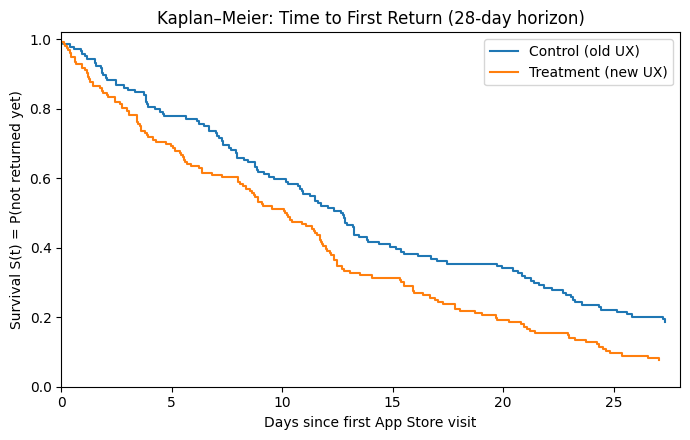

KM D28 return (control):   81.25%
KM D28 return (treatment): 92.31%
KM absolute lift:          11.06 pp
                       Results: PHReg
Model:                   PH Reg           Sample size:    300
Dependent variable:      duration_days    Num. events:    261
Ties:                    Breslow                             
-------------------------------------------------------------
          log HR log HR SE   HR     t    P>|t|  [0.025 0.975]
-------------------------------------------------------------
treatment 0.3840    0.1252 1.4682 3.0679 0.0022 1.1488 1.8764
Confidence intervals are for the hazard ratios
HR=1.468  95%CI [1.149, 1.876]
Cox-implied D28 return (control):   81.19%
Cox-implied D28 return (treatment): 91.40%
Cox-implied absolute lift:          10.21 pp
Bootstrap SE (lift): 3.62 pp
Bootstrap 95% CI:    [3.45, 16.87] pp


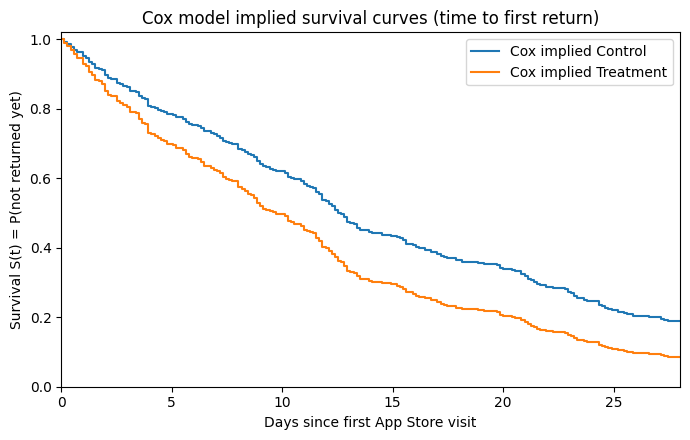

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime, timedelta
from statsmodels.duration.survfunc import SurvfuncRight
from statsmodels.duration.hazard_regression import PHReg

np.random.seed(42)

# ----------------------------
# 1) Build toy schema
# ----------------------------
n = 300
experiment_start = datetime(2026, 1, 1)
experiment_end   = datetime(2026, 2, 15)

merchant_id = np.arange(n)
treatment   = np.random.binomial(1, 0.5, size=n)

# First visit happens sometime in first 10 days
first_visit_ts = np.array([experiment_start + timedelta(days=int(d))
                           for d in np.random.randint(0, 10, size=n)])

# Simulate time-to-first-return (days): treatment makes returns faster (higher hazard)
hazard_control = 0.06
hazard_mult    = 1.25
hazard = hazard_control * np.where(treatment == 1, hazard_mult, 1.0)
time_to_return = np.random.exponential(scale=1.0 / hazard, size=n)

# Censor at min(28 days, experiment end)
censor_ts = np.array([min(fv + timedelta(days=28), experiment_end) for fv in first_visit_ts])

return_ts = []
event = np.zeros(n, dtype=int)
duration_days = np.zeros(n, dtype=float)

for i in range(n):
    fv = first_visit_ts[i]
    rt = fv + timedelta(days=float(time_to_return[i]))
    ct = censor_ts[i]
    if rt <= ct:
        return_ts.append(rt)
        event[i] = 1
        duration_days[i] = (rt - fv).total_seconds() / (3600 * 24)
    else:
        return_ts.append(pd.NaT)
        event[i] = 0
        duration_days[i] = (ct - fv).total_seconds() / (3600 * 24)

df = pd.DataFrame({
    "merchant_id": merchant_id,
    "treatment": treatment,
    "first_visit_ts": first_visit_ts,
    "return_ts": return_ts,
    "censor_ts": censor_ts,
    "duration_days": duration_days,
    "event": event,
})

# ----------------------------
# 2) Kaplan–Meier (KM) plot
# ----------------------------
control = df[df["treatment"] == 0]
treat   = df[df["treatment"] == 1]

km_c = SurvfuncRight(control["duration_days"], control["event"])
km_t = SurvfuncRight(treat["duration_days"], treat["event"])

plt.figure(figsize=(7, 4.5))
plt.step(km_c.surv_times, km_c.surv_prob, where="post", label="Control (old UX)")
plt.step(km_t.surv_times, km_t.surv_prob, where="post", label="Treatment (new UX)")
plt.xlabel("Days since first App Store visit")
plt.ylabel("Survival S(t) = P(not returned yet)")
plt.title("Kaplan–Meier: Time to First Return (28-day horizon)")
plt.ylim(0, 1.02); plt.xlim(0, 28)
plt.legend()
plt.tight_layout()
plt.show()

def km_survival_at(km, t=28.0):
    idx = np.searchsorted(km.surv_times, t, side="right") - 1
    return 1.0 if idx < 0 else float(km.surv_prob[idx])

S28_c_km = km_survival_at(km_c, 28.0)
S28_t_km = km_survival_at(km_t, 28.0)

ret28_c_km = 1 - S28_c_km
ret28_t_km = 1 - S28_t_km
print(f"KM D28 return (control):   {ret28_c_km*100:.2f}%")
print(f"KM D28 return (treatment): {ret28_t_km*100:.2f}%")
print(f"KM absolute lift:          {(ret28_t_km-ret28_c_km)*100:.2f} pp")

# ----------------------------
# 3) Cox PH model: HR for return
# ----------------------------
# IMPORTANT: Cox typically has NO intercept term.
exog = df[["treatment"]].astype(float)
cox = PHReg(endog=df["duration_days"], exog=exog, status=df["event"])
cox_res = cox.fit()
print(cox_res.summary())

beta = float(cox_res.params[0])        # log HR
se_beta = float(cox_res.bse[0])
hr = float(np.exp(beta))
ci_hr = (float(np.exp(beta - 1.96*se_beta)), float(np.exp(beta + 1.96*se_beta)))
print(f"HR={hr:.3f}  95%CI [{ci_hr[0]:.3f}, {ci_hr[1]:.3f}]")

# ----------------------------
# 4) Convert HR -> absolute D28 return pp lift
# ----------------------------
# Under Cox: S(t|x) = exp(-H0(t) * exp(x*beta))
# Statsmodels exposes baseline cumulative hazard as [times, cumhaz, survival] arrays.
base = cox_res.baseline_cumulative_hazard[0]
times  = np.asarray(base[0], dtype=float)   # event times
cumhaz = np.asarray(base[1], dtype=float)   # H0(t)

def step_cumhaz_at(t):
    idx = np.searchsorted(times, t, side="right") - 1
    return 0.0 if idx < 0 else float(cumhaz[idx])

t_eval = 28.0
H0_28 = step_cumhaz_at(t_eval)

S28_control = np.exp(-H0_28)                 # x=0
S28_treat   = np.exp(-H0_28 * np.exp(beta))  # x=1

ret28_control = 1 - S28_control
ret28_treat   = 1 - S28_treat
lift28_pp = (ret28_treat - ret28_control) * 100

print(f"Cox-implied D28 return (control):   {ret28_control*100:.2f}%")
print(f"Cox-implied D28 return (treatment): {ret28_treat*100:.2f}%")
print(f"Cox-implied absolute lift:          {lift28_pp:.2f} pp")

# ----------------------------
# 5) CI for absolute lift: bootstrap (resample merchants)
# ----------------------------
B = 300
boot = []
rng = np.random.default_rng(2026)

for _ in range(B):
    idx = rng.integers(0, len(df), size=len(df))
    samp = df.iloc[idx].reset_index(drop=True)

    try:
        exog_b = samp[["treatment"]].astype(float)
        res_b = PHReg(samp["duration_days"], exog_b, status=samp["event"]).fit(disp=0)

        beta_b = float(res_b.params[0])
        base_b = res_b.baseline_cumulative_hazard[0]
        times_b  = np.asarray(base_b[0], dtype=float)
        cumhaz_b = np.asarray(base_b[1], dtype=float)

        def step_cumhaz_b_at(t):
            j = np.searchsorted(times_b, t, side="right") - 1
            return 0.0 if j < 0 else float(cumhaz_b[j])

        H0_28_b = step_cumhaz_b_at(t_eval)
        S28_c_b = np.exp(-H0_28_b)
        S28_t_b = np.exp(-H0_28_b * np.exp(beta_b))
        lift_b  = ((1 - S28_t_b) - (1 - S28_c_b)) * 100
        boot.append(lift_b)
    except Exception:
        pass

boot = np.asarray(boot)
ci_low, ci_high = np.percentile(boot, [2.5, 97.5])
se_boot = float(np.std(boot, ddof=1))

print(f"Bootstrap SE (lift): {se_boot:.2f} pp")
print(f"Bootstrap 95% CI:    [{ci_low:.2f}, {ci_high:.2f}] pp")

# ----------------------------
# 6) Plot Cox-implied survival curves
# ----------------------------
grid = np.linspace(0, 28, 200)
H0_grid = np.array([step_cumhaz_at(t) for t in grid])
S_c_grid = np.exp(-H0_grid)
S_t_grid = np.exp(-H0_grid * np.exp(beta))

plt.figure(figsize=(7, 4.5))
plt.step(grid, S_c_grid, where="post", label="Cox implied Control")
plt.step(grid, S_t_grid, where="post", label="Cox implied Treatment")
plt.xlabel("Days since first App Store visit")
plt.ylabel("Survival S(t) = P(not returned yet)")
plt.title("Cox model implied survival curves (time to first return)")
plt.ylim(0, 1.02); plt.xlim(0, 28)
plt.legend()
plt.tight_layout()
plt.show()